In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!pip install tensorflow==2.12

In [3]:
%cd /content/drive/MyDrive/Cheating_enhancement/

/content/drive/MyDrive/Cheating_enhancement


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model

In [5]:
!pwd

/content/drive/MyDrive/Cheating_enhancement


In [6]:
#BATCH_SIZE = 32
BATCH_SIZE = 16
IMG_SIZE = [224, 224]
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"

In [7]:


# Setup directory paths and parameters
directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

In [8]:
# Load datasets
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.3,  # 30% for validation
                                             subset='training',
                                             seed=42)

validation_dataset = image_dataset_from_directory(directory,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE,
                                                  validation_split=0.2,  # 20% for validation
                                                  subset='validation',
                                                  seed=42)

test_dataset = image_dataset_from_directory(directory,
                                            shuffle=True,
                                            batch_size=BATCH_SIZE,
                                            image_size=IMG_SIZE,
                                            validation_split=0.1,  # 10% for testing
                                            subset='validation',
                                            seed=42)

Found 11581 files belonging to 2 classes.
Using 8107 files for training.
Found 11581 files belonging to 2 classes.
Using 2316 files for validation.
Found 11581 files belonging to 2 classes.
Using 1158 files for validation.


In [9]:

directory = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)
class_names = train_dataset.class_names
num_classes = len(class_names)

In [10]:
images = layers.Input(shape=IMG_SHAPE)

# Block 1
x = layers.Conv2D(filters=16, kernel_size=[1, 1], padding='same')(images)
block = layers.Conv2D(filters=16, kernel_size=[3, 3], padding="same")(x)
block = layers.BatchNormalization()(block)
block = layers.Activation("relu")(block)
block = layers.Conv2D(filters=16, kernel_size=[3, 3], padding="same")(block)

# Squeeze and Excitation 1
sq = layers.GlobalAveragePooling2D()(block)
sq = layers.Reshape((1, 1, 16))(sq)
sq = layers.Dense(units=16, activation="sigmoid")(sq)
block = layers.multiply([block, sq])

net = layers.add([x, block])
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2), name="block_1")(net)

# Block 2
x = layers.Conv2D(filters=32, kernel_size=[1, 1], padding='same')(net)
block = layers.Conv2D(filters=32, kernel_size=[3, 3], padding="same")(x)
block = layers.BatchNormalization()(block)
block = layers.Activation("relu")(block)
block = layers.Conv2D(filters=32, kernel_size=[3, 3], padding="same")(block)

# Squeeze and Excitation 2
sq = layers.GlobalAveragePooling2D()(block)
sq = layers.Reshape((1, 1, 32))(sq)
sq = layers.Dense(units=32, activation="sigmoid")(sq)
block = layers.multiply([block, sq])

net = layers.add([x, block])
net = layers.BatchNormalization()(net)
net = layers.Activation("relu")(net)
net = layers.MaxPooling2D(pool_size=(2, 2), name="block_2")(net)

# Block 3
x = layers.Conv2D(filters=64, kernel_size=[1, 1], padding='same')(net)
block = layers.Conv2D(filters=64, kernel_size=[3, 3], padding="same")(x)
block = layers.BatchNormalization()(block)
block = layers.Activation("relu")(block)
block = layers.Conv2D(filters=64, kernel_size=[3, 3], padding="same")(block)

# Squeeze and Excitation 3
sq = layers.GlobalAveragePooling2D()(block)
sq = layers.Reshape((1, 1, 64))(sq)
sq = layers.Dense(units=64, activation="sigmoid")(sq)
block = layers.multiply([block, sq])

net = layers.add([x, block])
net = layers.BatchNormalization()(net)
net = layers.Activation("relu", name="block_3")(net)
net = layers.Dropout(0.25)(net)

net = layers.GlobalAveragePooling2D()(net)
net = layers.Dense(units=1, activation="sigmoid")(net)
# Create model
model = Model(inputs=images, outputs=net)


In [11]:
# Compile the model for binary classification
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy'])


In [ ]:
# Train the model
import time
t1 = time.time()
initial_epochs = 60
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=initial_epochs)
t2 = time.time()
print(f"Training time: {t2 - t1} seconds")

Epoch 1/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 411s 776ms/step - accuracy: 0.7315 - loss: 0.5408 - val_accuracy: 0.6161 - val_loss: 0.9532
Epoch 2/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7912 - loss: 0.4564 - val_accuracy: 0.6978 - val_loss: 0.7244
Epoch 3/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7969 - loss: 0.4270 - val_accuracy: 0.7310 - val_loss: 0.7035
Epoch 4/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8282 - loss: 0.3846 - val_accuracy: 0.8342 - val_loss: 0.3826
Epoch 5/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8449 - loss: 0.3678 - val_accuracy: 0.6762 - val_loss: 1.2826
Epoch 6/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8538 - loss: 0.3497 - val_accuracy: 0.6593 - val_loss: 0.9271
Epoch 7/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8616 - loss: 0.3321 - val_accuracy: 0.8726 - val_loss: 0.3247
Epoch 8/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8609 - loss: 0.3164 

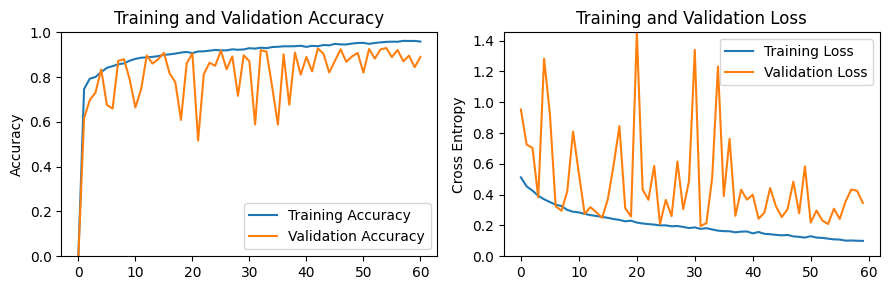

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training and Validation Accuracy')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Cross Entropy')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training and Validation Loss')
plt.tight_layout()
plt.show()

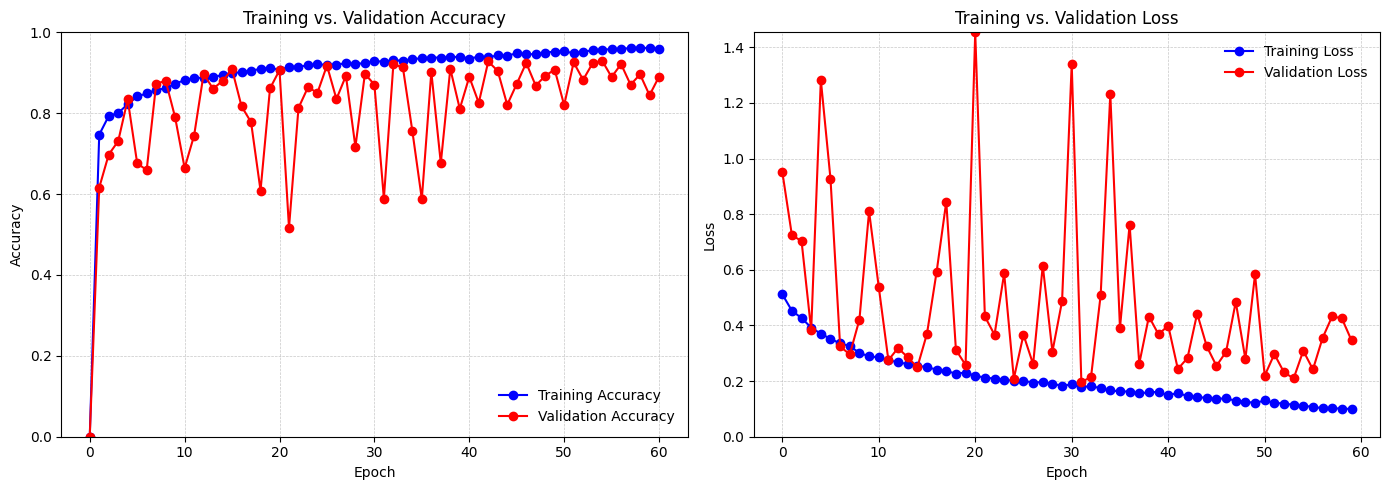

In [ ]:
import matplotlib.pyplot as plt

# Sample Data (replace with your actual history data)
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training and Validation Accuracy Plot
ax1.plot(acc, marker='o', linestyle='-', color='blue', label='Training Accuracy')
ax1.plot(val_acc, marker='o', linestyle='-', color='red', label='Validation Accuracy')
ax1.legend(loc='lower right', fontsize=10, frameon=False)  # Legend inside the plot, lower right
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training vs. Validation Accuracy')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Training and Validation Loss Plot
ax2.plot(loss, marker='o', linestyle='-', color='blue', label='Training Loss')
ax2.plot(val_loss, marker='o', linestyle='-', color='red', label='Validation Loss')
ax2.legend(loc='upper right', fontsize=10, frameon=False)  # Legend inside the plot, upper right
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training vs. Validation Loss')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Adjust layout and background color
fig.patch.set_facecolor('white')  # Set figure background to white
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to fit everything nicely
plt.show()


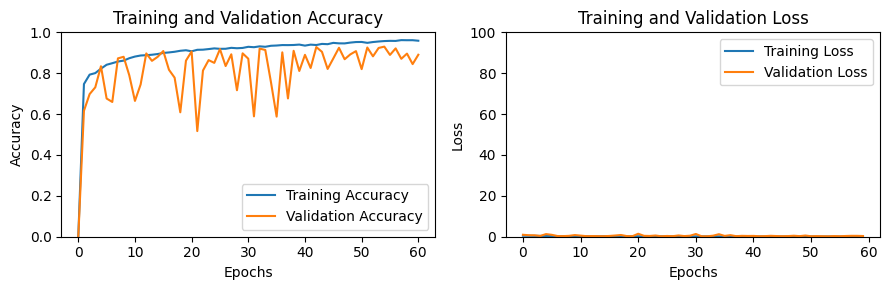

In [ ]:
# Plotting training results
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# Accuracy plot
ax1.plot(range(61), acc, label='Training Accuracy')  # X-axis now spans 61 epochs (0 to 60)
ax1.plot(range(61), val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])  # Keeping accuracy y-axis between min and 1
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')

# Loss plot with adjusted range
ax2.plot(range(60), loss, label='Training Loss')  # Adjusting to ensure it spans the right number of epochs
ax2.plot(range(60), val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, 100])  # Set y-axis of loss plot between 0 and 100
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')

plt.tight_layout()
plt.show()


In [ ]:
# Evaluate the model on the training dataset
train_loss, *train_metrics = model.evaluate(train_dataset)
print("Training Loss:", train_loss)
print("Training Metrics:", train_metrics)

# Evaluate the model on the validation dataset
val_loss, *val_metrics = model.evaluate(validation_dataset)
print("Validation Loss:", val_loss)
print("Validation Metrics:", val_metrics)


507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9122 - loss: 0.2246
Training Loss: 0.21521170437335968
Training Metrics: [0.9183421730995178]
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8914 - loss: 0.3648
Validation Loss: 0.34618642926216125
Validation Metrics: [0.8903281688690186]


In [ ]:
import time

# Start the timer
t3 = time.time()

# Evaluate the model on the test dataset
test_loss, *test_metrics = model.evaluate(test_dataset)

# End the timer
t4 = time.time()

# Calculate and print the execution time
temps_execution = t4 - t3
print(f"Le temps d'exécution est de {temps_execution} secondes.")

# Print the test loss and metrics
print("Test Loss:", test_loss)
print("Test Metrics:", test_metrics)


73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8899 - loss: 0.3453
Le temps d'exécution est de 3.1706414222717285 secondes.
Test Loss: 0.329874724149704
Test Metrics: [0.8903281688690186]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Setup directory paths and parameters

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━

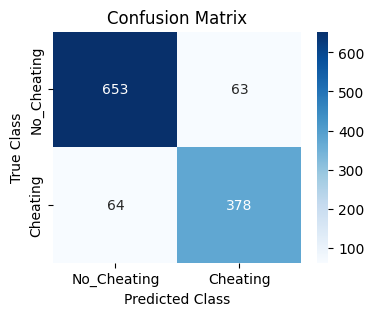

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predicted labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())  # Get the true labels
    predictions = model.predict(images)  # Get model predictions
    y_pred.extend((predictions > 0.5).astype(int).flatten())  # Threshold for binary classification

# Define binary class names
class_names = ["No_Cheating", "Cheating"]

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))  # Set the figure size to 3x4
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()


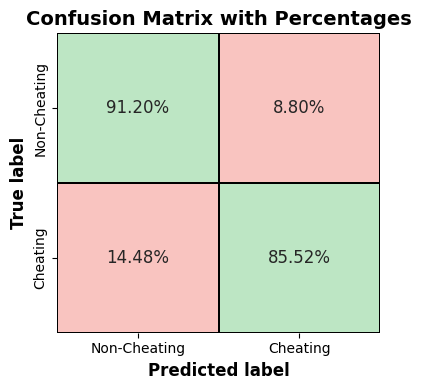

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate the percentages
cf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the labels with percentages
labels = [f'{value:.2f}%' for value in cf_matrix_percent.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels (matching appearance from the previous code)
ax.set_title('Confusion Matrix with Percentages', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


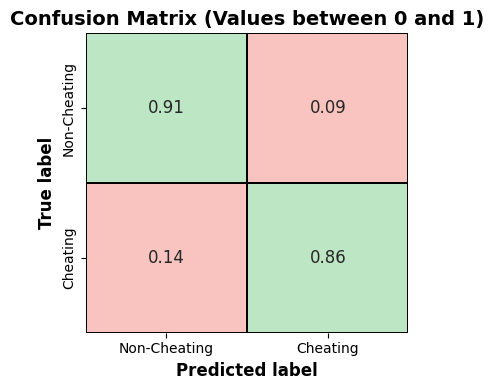

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


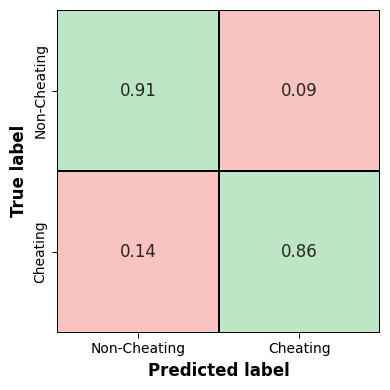

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
#ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already defined

# Calculate accuracy, precision, recall, and f1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='binary')  # Use 'binary' for binary classification, or 'macro', 'micro' for multi-class
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.89
Precision: 0.86
Recall: 0.86
F1 Score: 0.86


AUC for our classifier is: 0.88


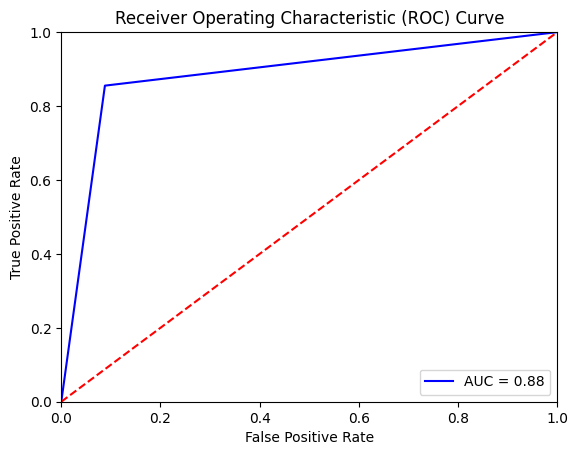

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ROC Curve
fpr, tpr, threshold = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc:.2f}")

# Plotting the ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
%cd /content/drive/MyDrive/Cheating_enhancement/
# Saving the model in HDF5 format
model_save_path = 'saved_models/se_resnet2_d1.h5'
model.save(model_save_path)

/content/drive/MyDrive/Cheating_enhancement


In [ ]:
import tensorflow as tf
%cd /content/drive/MyDrive/Cheating_enhancement/
# Specify the path to the saved model directory
model_path = 'saved_models/se_resnet2_d1.h5'

# Load the trained model
model = tf.keras.models.load_model(model_path)

# The model is ready to use in inference mode

/content/drive/MyDrive/Cheating_enhancement


In [ ]:
import time

# Initialize variables to accumulate time and count images
total_time = 0
num_images = 0

# Loop over the dataset to measure time for each image
for images, labels in test_dataset:
    start_time = time.time()
    _ = model.evaluate(images, labels, verbose=0)  # Evaluate on a single batch (1 image at a time if batch size is 1)
    end_time = time.time()

    # Accumulate time and count
    total_time += (end_time - start_time)
    num_images += images.shape[0]  # Add number of images in the batch
print(total_time )
print(f"test time: {total_time:.4f} seconds")
print('---------------------')
print( num_images)
print('---------------------')
# Calculate average time per image
average_time_per_image = total_time / num_images
print(f"Average time per image: {average_time_per_image:.4f} seconds")


10.063891887664795
test time: 10.0639 seconds
---------------------
1158
---------------------
Average time per image: 0.0087 seconds


In [12]:
import time

# Limit the test dataset to the first 960 images
test_limited = test_dataset.take(960)

# Start timing
start_time = time.time()

# Run the model on the limited test dataset to get predictions
predictions = model.predict(test_limited)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = 960  # Since we are only taking 960 images

print(f"Total inference time for 960 images: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")

73/73 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step
Total inference time for 960 images: 183.7875 seconds
Average time per image: 0.1914 seconds
